<a href="https://colab.research.google.com/github/VARU2224/Anomaly-Detection-time-/blob/main/Level_1_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


**# Level 1 - Task 1: Top Cuisines**

## Objective
The objective of this task is to identify the three most common cuisines in the dataset and calculate the percentage of restaurants serving each cuisine. This analysis helps understand customer food preferences and the popularity of different cuisines.

In [ ]:
# Display the column names
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [ ]:
# Split multiple cuisines and count each cuisine separately
cuisine_counts = (
    df['Cuisines']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

# Display the top 3 cuisines
top3 = cuisine_counts.head(3)

print("Top 3 Most Common Cuisines:")
print(top3)

Top 3 Most Common Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [ ]:
# Calculate the percentage of restaurants serving each top cuisine
total_restaurants = len(df)

percentage = (top3 / total_restaurants) * 100

print("Percentage of Restaurants Serving Top 3 Cuisines:")
print(percentage.round(2))

Percentage of Restaurants Serving Top 3 Cuisines:
Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


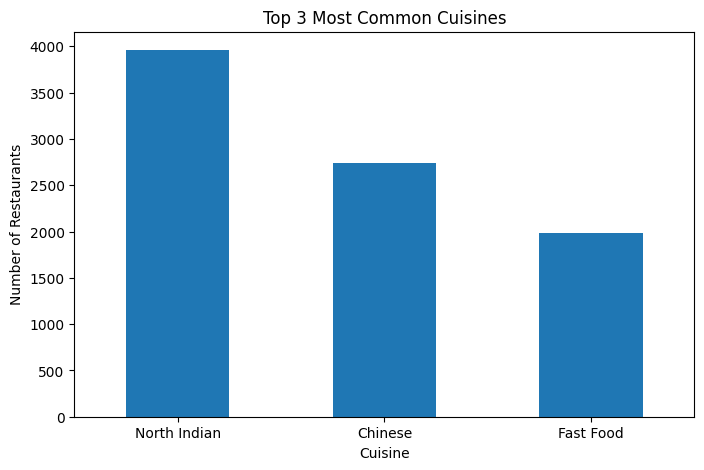

In [ ]:
plt.figure(figsize=(8,5))
top3.plot(kind='bar')

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

## Conclusion

The analysis shows the three most common cuisines available in the restaurant dataset. These cuisines dominate the market and are served by a large number of restaurants. Understanding cuisine popularity helps businesses identify customer preferences and make better decisions regarding menu planning and restaurant expansion.

**# Level 1 - Task 2: City Analysis**

In this task, I analyzed the restaurant data to find out which city has the highest number of restaurants. I also calculated the average rating for restaurants in each city and identified the city with the highest average rating. This analysis helps understand restaurant distribution and customer satisfaction across different cities.

In [ ]:
# Count the number of restaurants in each city
city_counts = df['City'].value_counts()

print("City with the Highest Number of Restaurants:")
print(city_counts.head(1))

City with the Highest Number of Restaurants:
City
New Delhi    5473
Name: count, dtype: int64


In [ ]:
# Display the top 10 cities with the most restaurants
print("Top 10 Cities by Number of Restaurants:")
print(city_counts.head(10))

Top 10 Cities by Number of Restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


In [ ]:
# Calculate average rating for each city
city_ratings = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print("Average Rating of Restaurants in Each City:")
print(city_ratings)

Average Rating of Restaurants in Each City:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [ ]:
# Display the city with the highest average rating
print("City with the Highest Average Rating:")
print(city_ratings.head(1))

City with the Highest Average Rating:
City
Inner City    4.9
Name: Aggregate rating, dtype: float64


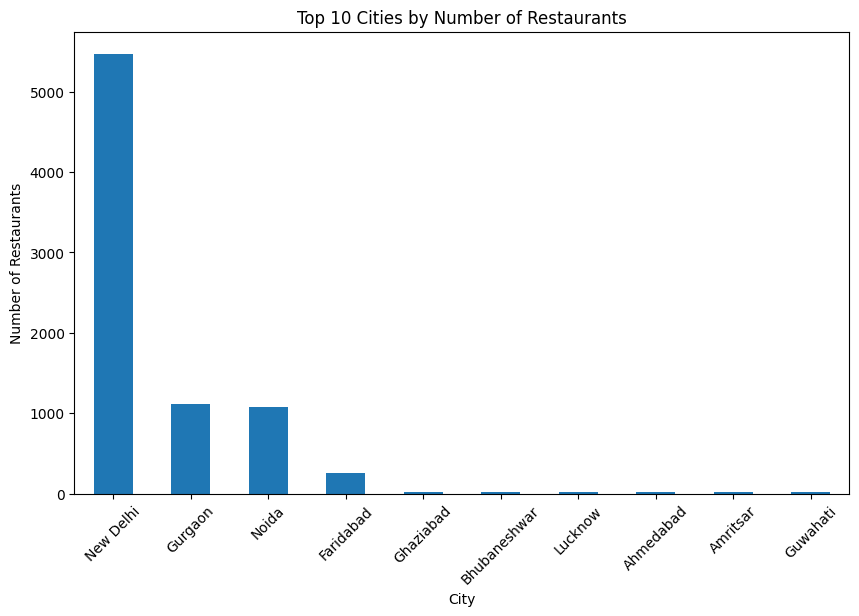

In [ ]:
plt.figure(figsize=(10,6))

city_counts.head(10).plot(kind='bar')

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

## Conclusion

From this analysis, I found that some cities have significantly more restaurants than others. I also observed that a city with a large number of restaurants does not always have the highest average rating. These findings show how restaurant popularity and customer satisfaction can vary from one city to another.

**# Level 1 - Task 3: Price Range Distribution**

## Objective

In this task, I analyzed the distribution of restaurants based on their price range. I also calculated the percentage of restaurants in each price category and visualized the results using a bar chart. This helps in understanding the affordability of restaurants available in the dataset.

In [ ]:
# Count restaurants in each price range
price_counts = df['Price range'].value_counts().sort_index()

print("Number of Restaurants in Each Price Range:")
print(price_counts)

Number of Restaurants in Each Price Range:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [ ]:
# Calculate percentage of restaurants in each price range
price_percentage = (price_counts / len(df)) * 100

print("Percentage of Restaurants in Each Price Range:")
print(price_percentage.round(2))

Percentage of Restaurants in Each Price Range:
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


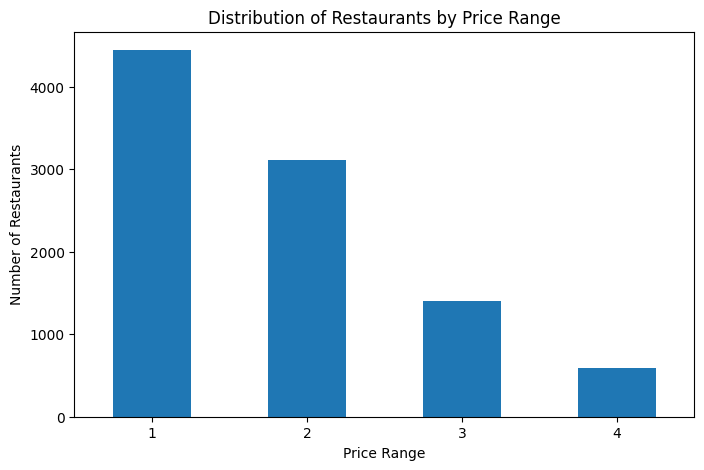

In [ ]:
plt.figure(figsize=(8,5))

price_counts.plot(kind='bar')

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)

plt.show()

## Observation

- Price Range __ has the highest number of restaurants.
- Price Range __ has the lowest number of restaurants.
- Most restaurants fall into the lower/mid price categories, indicating that affordable dining options are more common in the dataset.

Price Range 1 has the highest number of restaurants.
Price Range 4 has the lowest number of restaurants.
This suggests that budget-friendly restaurants are more common than premium restaurants in the dataset.

## Conclusion

This analysis shows how restaurants are distributed across different price ranges. It helps in understanding customer affordability and market trends. The visualization clearly indicates which price category has the highest concentration of restaurants.

**# Level 1 - Task 4: Online Delivery**

## Objective
In this task, I examined how many restaurants offer online delivery and compared their average ratings with restaurants that do not provide this service. This analysis helps understand whether online delivery has any impact on customer ratings.

In [ ]:
# Display the values in the online delivery column
print(df['Has Online delivery'].value_counts())

In [ ]:
# Count restaurants with and without online delivery
delivery_counts = df['Has Online delivery'].value_counts()

# Calculate percentage
delivery_percentage = (delivery_counts / delivery_counts.sum()) * 100

print("Percentage of Restaurants Offering Online Delivery:")
print(delivery_percentage.round(2))

In [ ]:
# Compare average ratings
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print("Average Rating Based on Online Delivery:")
print(delivery_rating.round(2))

In [ ]:
plt.figure(figsize=(6,5))

delivery_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)

plt.show()

In [ ]:
plt.figure(figsize=(6,5))

delivery_rating.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Average Restaurant Rating by Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.show()

## Observation

- Most restaurants in the dataset do not offer online delivery.
- Restaurants with online delivery have an average rating of 3.25.
- Restaurants without online delivery have an average rating of 2.46.
- Based on these results, restaurants with online delivery have slightly higher ratings, although ratings are also influenced by other factors.

## Conclusion

From this task, I learned how to compare restaurant ratings using grouped data in Python. I found that online delivery is not available at every restaurant, and there is a slight difference in the average ratings between restaurants that offer online delivery and those that do not. This task helped me understand how data analysis can be used to compare different business features.